# Final Project MLOps: Pseudo-Labeling and Feature Engineering (CP1)

Greycia Febrina Michelle & Aulia Aca Azzahra, SISTECH 2026

What changed for the final project: Hands-On 1 and 2 produced a static table, one row per combination of grid cell, day of week, and hour that had at least one historical crime. The final project needs a function that can answer a query for any coordinate and any timestamp, including locations that never had a recorded crime nearby. A static table cannot represent that case at all, so part of this notebook is really an architecture change, not just a parameter change.

What the mentor flagged on Hands-On 1: the hour 0 spike in the data was documented as a likely data quality artifact but never actually handled in the pipeline, and the hotspot comparison between the crime density map and the risk score map was visual only, never tested with a real correlation number. Both are addressed here with actual computation, not just written as future work again.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

PRIMARY = "#A1007E"
ACCENT = "#D6008C"
TITLE_CLR = "#2A2882"

plt.rcParams["axes.titlecolor"] = TITLE_CLR

print("Setup complete")

Setup complete


## Loading the Event-Level Dataset

`events_scored.csv` is the per-event dataset produced during Hands-On 1, before it gets collapsed into the grid summary table. It still has the original timestamp for every crime, together with the severity score already computed for it. This is the file the rest of this notebook works from, not the aggregated `features_labels.csv`.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/SISTECH/events_scored.csv"
events = pd.read_csv(DATA_PATH, parse_dates=["Datetime"])

print(f"Rows: {len(events):,}")
print(f"Date range: {events['Datetime'].min()} to {events['Datetime'].max()}")
events.head(3)

Rows: 550,896
Date range: 2024-01-01 00:00:00 to 2026-04-11 00:00:00


,Datetime,cell_id,lat_r,lon_r,dow,hour,Primary Type,Description,severity,age_days,w_time,event_value
0,2026-04-11,41.8_-87.65,41.80,-87.65,5,0,THEFT,$500 AND UNDER,16.0,0.0,1.0,16.0
1,2026-04-11,41.88_-87.68,41.88,-87.68,5,0,BATTERY,SIMPLE,38.0,0.0,1.0,38.0
2,2026-04-11,41.98_-87.7,41.98,-87.70,5,0,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,18.0,0.0,1.0,18.0


## From a Static Table to a Query Function

Hands-On 1 built `unit`, a table grouped by cell, day of week, and hour, then computed one risk score per row. That works for training a model later, but it cannot answer "what is the risk at this exact coordinate right now" unless that exact coordinate already happens to be a cell with recorded history.

The final project's example table makes this gap concrete. One of the four rows is "no crime within radius, risk score equals zero exactly." A groupby table never produces that row, because groupby only ever returns combinations that already exist in the data.

The fix here is to rewrite severity, decay, and spatial weighting as a function that takes a coordinate and a timestamp directly, searches nearby historical events at call time, and returns zero cleanly when nothing relevant is found nearby. The severity table itself is unchanged from Hands-On 1 and 2, it is reused as is below.

In [4]:
SEVERITY_DEFAULT_BY_TYPE = {
    "HOMICIDE": 100, "CRIMINAL SEXUAL ASSAULT": 92, "SEX OFFENSE": 60,
    "KIDNAPPING": 88, "HUMAN TRAFFICKING": 88, "OFFENSE INVOLVING CHILDREN": 70,
    "ROBBERY": 68, "ARSON": 65, "ASSAULT": 50, "BATTERY": 45,
    "STALKING": 45, "WEAPONS VIOLATION": 45, "INTIMIDATION": 40, "BURGLARY": 40,
    "MOTOR VEHICLE THEFT": 32, "THEFT": 28, "NARCOTICS": 22, "OTHER NARCOTIC VIOLATION": 20,
    "CRIMINAL DAMAGE": 18, "DECEPTIVE PRACTICE": 18, "CRIMINAL TRESPASS": 14,
    "OTHER OFFENSE": 14, "PROSTITUTION": 12, "PUBLIC PEACE VIOLATION": 12,
    "PUBLIC INDECENCY": 12, "OBSCENITY": 15, "INTERFERENCE WITH PUBLIC OFFICER": 25,
    "GAMBLING": 6, "LIQUOR LAW VIOLATION": 6, "CONCEALED CARRY LICENSE VIOLATION": 8,
    "NON-CRIMINAL": 5,
}

SEVERITY_OVERRIDE = {
    ("BATTERY", "DOMESTIC BATTERY SIMPLE"): 42,
    ("BATTERY", "SIMPLE"): 38,
    ("BATTERY", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 75,
    ("BATTERY", "AGGRAVATED - HANDGUN"): 85,
    ("THEFT", "$500 AND UNDER"): 16,
    ("THEFT", "OVER $500"): 30,
    ("THEFT", "RETAIL THEFT"): 12,
    ("THEFT", "FROM BUILDING"): 25,
    ("THEFT", "THEFT FROM MOTOR VEHICLE"): 22,
    ("THEFT", "FROM PERSON"): 40,
    ("CRIMINAL DAMAGE", "TO VEHICLE"): 14,
    ("CRIMINAL DAMAGE", "TO PROPERTY"): 16,
    ("ASSAULT", "SIMPLE"): 28,
    ("ASSAULT", "AGGRAVATED - HANDGUN"): 78,
    ("ASSAULT", "AGGRAVATED - KNIFE / CUTTING INSTRUMENT"): 70,
    ("WEAPONS VIOLATION", "UNLAWFUL POSSESSION - HANDGUN"): 50,
    ("BURGLARY", "FORCIBLE ENTRY"): 52,
    ("BURGLARY", "UNLAWFUL ENTRY"): 38,
    ("BURGLARY", "BURGLARY FROM MOTOR VEHICLE"): 30,
    ("OTHER OFFENSE", "TELEPHONE THREAT"): 20,
    ("OTHER OFFENSE", "HARASSMENT BY TELEPHONE"): 15,
    ("OTHER OFFENSE", "HARASSMENT BY ELECTRONIC MEANS"): 15,
    ("OTHER OFFENSE", "VIOLATE ORDER OF PROTECTION"): 35,
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT OVER $ 300"): 25,
    ("DECEPTIVE PRACTICE", "CREDIT CARD FRAUD"): 20,
    ("ROBBERY", "ARMED - HANDGUN"): 88,
    ("ROBBERY", "STRONG ARM - NO WEAPON"): 55,
    ("MOTOR VEHICLE THEFT", "ATTEMPT - AUTOMOBILE"): 20,
}

GLOBAL_FALLBACK_SEVERITY = 15

print("Severity table reused from Hands-On 1 and 2, unchanged")

Severity table reused from Hands-On 1 and 2, unchanged


## Recalibrating the Temporal Decay

Hands-On 2 used a half life of 120 days for the exponential decay, chosen at the time from the continual learning batch schedule. The final project comes with its own example table, and one row conflicts with that choice directly: a crime from two years ago at the same grid cell is expected to carry a weight of about 0.14, not close to zero.

A half life is checked against that target instead of guessed again.

In [5]:
target_age_days = 730
target_weight = 0.14

lam = -np.log(target_weight) / target_age_days
half_life_days = np.log(2) / lam

print(f"Calibrated half life: {half_life_days:.1f} days")

for candidate in [120, round(half_life_days), 260]:
    lam_check = np.log(2) / candidate
    w_yesterday = np.exp(-lam_check * 1)
    w_two_years = np.exp(-lam_check * 730)
    print(f"half_life={candidate:>3} days -> weight yesterday={w_yesterday:.4f}, weight two years ago={w_two_years:.4f}")

Calibrated half life: 257.4 days
half_life=120 days -> weight yesterday=0.9942, weight two years ago=0.0147
half_life=257 days -> weight yesterday=0.9973, weight two years ago=0.1396
half_life=260 days -> weight yesterday=0.9973, weight two years ago=0.1428


257 days matches both rows of the example table at once, close to 1.0 for yesterday and close to 0.14 for two years ago. This is the value used from here on, replacing the 120 days used in Hands-On 2. Anyone re-checking the model trained in Hands-On 2 should expect its outputs to shift once this new half life is in place, since older events now carry more weight than before.

In [6]:
HALF_LIFE_DAYS = round(half_life_days)
LAMBDA = np.log(2) / HALF_LIFE_DAYS
print(f"HALF_LIFE_DAYS = {HALF_LIFE_DAYS}, LAMBDA = {LAMBDA:.6f}")

HALF_LIFE_DAYS = 257, LAMBDA = 0.002697


## Handling the Hour 0 Data Quality Issue

Hands-On 1 noted a spike in reported crimes at exactly hour 0, likely from records where the exact time was unknown and defaulted to midnight. That note never turned into an actual fix. It does now, checked against the real data first.

In [7]:
exact_midnight = (
    (events["Datetime"].dt.hour == 0)
    & (events["Datetime"].dt.minute == 0)
    & (events["Datetime"].dt.second == 0)
)
print(f"Events at exactly 00:00:00: {exact_midnight.sum():,} ({exact_midnight.mean()*100:.2f}% of all events)")

hour0 = events[events["Datetime"].dt.hour == 0]
hour14 = events[events["Datetime"].dt.hour == 14]
print(f"Within hour 0, minute also equals 0: {(hour0['Datetime'].dt.minute == 0).mean()*100:.1f}%")
print(f"Within hour 14, minute also equals 0: {(hour14['Datetime'].dt.minute == 0).mean()*100:.1f}%")

Events at exactly 00:00:00: 19,529 (3.54% of all events)
Within hour 0, minute also equals 0: 52.4%
Within hour 14, minute also equals 0: 29.0%


Within hour 0, more than half of all records also land on minute 0 exactly. At hour 14, an ordinary afternoon hour, only about 29 percent do, and that 29 percent is just the general rounding-to-the-quarter-hour habit already seen across the whole dataset. The extra concentration specific to hour 0 is consistent with a placeholder timestamp for an unknown time of day, not a real spike in midnight crime.

The fix applied in the scoring function below: events timestamped at exactly 00:00:00 are treated as having an unknown hour. They still count fully toward recency and spatial proximity, but they do not get weighted toward or away from any particular hour of day, since the recorded hour cannot be trusted for them specifically.

## Query-Time Scoring Function

`compute_risk_raw` takes a coordinate, an hour, the full event history, and a reference date representing the current point in time. It looks for historical events near that coordinate, weighs each one by how severe it was, how recently it happened, how close it was, and how similar its hour of day is to the hour being asked about, then sums the contributions. If nothing is found nearby, it returns zero directly, which is the behavior the example table asks for.

Hour similarity is a soft, circular weight rather than an exact match on day of week and hour like Hands-On 1 used. A crime from yesterday will usually fall on a different day of the week than today, and an exact match would have thrown that crime out entirely just for landing on the wrong weekday, even though it happened yesterday and should clearly matter. Circular hour distance also means hour 23 and hour 1 are treated as close together, the same reasoning already used for the cyclical encoding in Hands-On 1.

In [8]:
EARTH_RADIUS_M = 6371000
BANDWIDTH_M = 400
RADIUS_M = 1200
HOUR_BANDWIDTH = 4


def score_severity(primary_type, description):
    key = (primary_type, description)
    if key in SEVERITY_OVERRIDE:
        return SEVERITY_OVERRIDE[key]
    return SEVERITY_DEFAULT_BY_TYPE.get(primary_type, GLOBAL_FALLBACK_SEVERITY)


def haversine_m(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(a))


def hour_circular_distance(hour_a, hour_b):
    diff = np.abs(hour_a - hour_b) % 24
    return np.minimum(diff, 24 - diff)


def compute_risk_raw(query_lat, query_lon, query_hour, events, reference_date,
                      half_life_days=HALF_LIFE_DAYS, bandwidth_m=BANDWIDTH_M,
                      radius_m=RADIUS_M, hour_bandwidth=HOUR_BANDWIDTH):
    candidates = events[events["Datetime"] <= reference_date]
    dist_m = haversine_m(query_lat, query_lon, candidates["lat_r"].values, candidates["lon_r"].values)
    nearby_mask = dist_m <= radius_m
    nearby = candidates[nearby_mask]
    nearby_dist = dist_m[nearby_mask]

    if len(nearby) == 0:
        return 0.0

    age_days = (reference_date - nearby["Datetime"]).dt.total_seconds() / 86400
    lam = np.log(2) / half_life_days
    w_time = np.exp(-lam * age_days)
    w_space = np.exp(-0.5 * (nearby_dist / bandwidth_m) ** 2)

    is_exact_midnight = (
        (nearby["Datetime"].dt.hour == 0)
        & (nearby["Datetime"].dt.minute == 0)
        & (nearby["Datetime"].dt.second == 0)
    )
    hour_dist = hour_circular_distance(nearby["hour"].values, query_hour)
    w_hour = np.exp(-0.5 * (hour_dist / hour_bandwidth) ** 2)
    w_hour = np.where(is_exact_midnight.values, 1.0, w_hour)

    return float((nearby["severity"].values * w_time.values * w_space * w_hour).sum())

One design choice worth being explicit about: the filter `events["Datetime"] <= reference_date` matters more than it looks. Without it, a query about a past date would still pick up crimes that, relative to that past date, have not happened yet, and the age calculation would go negative, inflating the weight instead of correctly giving it zero influence. This exact mistake showed up once already during Hands-On 2's continual learning work, so it is guarded against here from the start rather than found again the same way.

## Calibrating the Normalization Ceiling

The raw weighted sum from `compute_risk_raw` has no fixed upper bound, so it needs to be compressed into a 0 to 100 scale the same way Hands-On 1 did it, with log1p followed by scaling against a ceiling taken from the 99th percentile of a sample. The ceiling has to be refit here because the half life and the hour weighting both changed, which changes the whole distribution of raw values, not just a few numbers.

In [9]:
def calibrate_clip_bound(events, reference_date, n_cells=200, hours=None, percentile=99, random_state=42):
    if hours is None:
        hours = [0, 3, 6, 9, 12, 15, 18, 21]

    cells_unique = events[["lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
    sample_cells = cells_unique.sample(min(n_cells, len(cells_unique)), random_state=random_state)

    raw_values = []
    for _, row in sample_cells.iterrows():
        for h in hours:
            raw_values.append(compute_risk_raw(row["lat_r"], row["lon_r"], h, events, reference_date))

    raw_values = np.array(raw_values)
    return float(np.percentile(np.log1p(raw_values), percentile))


REFERENCE_DATE = events["Datetime"].max()
CLIP_BOUND = calibrate_clip_bound(events, REFERENCE_DATE)
print(f"Reference date: {REFERENCE_DATE}")
print(f"Clip bound: {CLIP_BOUND:.4f}")

Reference date: 2026-04-11 00:00:00
Clip bound: 10.0613


In [10]:
def predict_risk_score(query_lat, query_lon, query_datetime, events, reference_date,
                        clip_bound, half_life_days=HALF_LIFE_DAYS,
                        bandwidth_m=BANDWIDTH_M, radius_m=RADIUS_M, hour_bandwidth=HOUR_BANDWIDTH):
    risk_raw = compute_risk_raw(query_lat, query_lon, query_datetime.hour, events, reference_date,
                                 half_life_days, bandwidth_m, radius_m, hour_bandwidth)
    log_val = np.log1p(risk_raw)
    clipped = min(log_val, clip_bound)
    return float(100 * clipped / clip_bound)

## Checking Behavior Against the Example Table

The final project document gives four rows of expected behavior. Each one is tested here with a single synthetic crime placed at a known distance and age, so the effect of recency and distance can be seen in isolation, without hundreds of real historical events blending together.

In [11]:
from datetime import timedelta

query_time = pd.Timestamp("2026-04-11 20:00:00")
reference_time = pd.Timestamp("2026-04-11")
query_lat, query_lon = 41.90, -87.63
severity_value = 70

def make_single_event(days_ago, lat, lon):
    dt = query_time - timedelta(days=days_ago)
    return pd.DataFrame([{"Datetime": dt, "lat_r": lat, "lon_r": lon, "hour": dt.hour, "severity": severity_value}])

scenarios = {
    "Crime yesterday, same grid cell": make_single_event(1, query_lat, query_lon),
    "Crime two years ago, same grid cell": make_single_event(730, query_lat, query_lon),
    "Crime yesterday, neighboring cell about 1km away": make_single_event(1, query_lat + 0.009, query_lon),
    "No crime within radius": make_single_event(1, query_lat + 0.05, query_lon),
}

for label, synthetic_events in scenarios.items():
    score = predict_risk_score(query_lat, query_lon, query_time, synthetic_events, reference_time, CLIP_BOUND)
    print(f"{label}: risk_score = {round(score, 2)}")

Crime yesterday, same grid cell: risk_score = 42.36
Crime two years ago, same grid cell: risk_score = 23.65
Crime yesterday, neighboring cell about 1km away: risk_score = 13.93
No crime within radius: risk_score = 0.0


The ordering comes out correct: recent and close scores highest, old but close scores lower, recent but far scores lower still, and no nearby crime returns exactly zero. What does not match cleanly are the exact category labels in the document, "very high", "medium", "low to medium". A single isolated synthetic crime cannot be compared directly against a category system built from real Chicago locations, most of which have accumulated years of history, not one event. That comparison is handled properly in the next section, using the actual distribution of scores across real locations rather than one invented example.

## Calibrating Risk Level Categories from Real Data

`level` in the API response needs to be a category, not just the raw number. Rather than picking round numbers for the boundaries, the boundaries are read off the actual distribution of scores across a sample of real locations and hours.

In [12]:
cell_lookup = events[["lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
sample_cells = cell_lookup.sample(200, random_state=42)
sample_hours = [0, 3, 6, 9, 12, 15, 18, 21]

sampled_scores = []
for _, row in sample_cells.iterrows():
    for h in sample_hours:
        raw = compute_risk_raw(row["lat_r"], row["lon_r"], h, events, REFERENCE_DATE)
        score = 100 * min(np.log1p(raw), CLIP_BOUND) / CLIP_BOUND
        sampled_scores.append(score)

sampled_scores = np.array(sampled_scores)
for p in [10, 25, 50, 75, 80, 90, 95]:
    print(f"percentile {p}: {np.percentile(sampled_scores, p):.2f}")

percentile 10: 58.24
percentile 25: 70.72
percentile 50: 82.32
percentile 75: 88.72
percentile 80: 90.14
percentile 90: 93.39
percentile 95: 95.76


Most real locations, once they have any recorded history at all, land on the high side of the 0 to 100 scale, because the scoring formula accumulates contributions across three years of data. This is expected given how the score is built, but it means fixed round-number thresholds like 40 and 70 would put almost everything into the top category. The boundaries below use the 25th and 80th percentiles of this sample instead, so the three categories actually split the real range of outcomes into meaningful groups rather than one category swallowing most of the data.

In [13]:
LOW_THRESHOLD = float(np.percentile(sampled_scores, 25))
HIGH_THRESHOLD = float(np.percentile(sampled_scores, 80))
print(f"LOW_THRESHOLD = {LOW_THRESHOLD:.2f}")
print(f"HIGH_THRESHOLD = {HIGH_THRESHOLD:.2f}")

LOW_THRESHOLD = 70.72
HIGH_THRESHOLD = 90.14


One gap remains even with data-driven thresholds. A severe crime that happened a few hours ago right at the query location will not necessarily push the accumulated score above a threshold calibrated on years of history, yet it clearly deserves to be flagged as high risk regardless of what the area's long-run average looks like. A direct override handles that case: if a sufficiently severe crime happened very recently and very close by, the level is forced to High no matter what the underlying score says. This is a deliberate product decision, favoring an over-warning on a fresh serious incident over strictly following the historical average.

In [14]:
def has_recent_nearby_incident(query_lat, query_lon, events, reference_date,
                                radius_m=300, recency_days=3, severity_threshold=50):
    candidates = events[events["Datetime"] <= reference_date]
    dist_m = haversine_m(query_lat, query_lon, candidates["lat_r"].values, candidates["lon_r"].values)
    age_days = (reference_date - candidates["Datetime"]).dt.total_seconds() / 86400

    mask = (
        (dist_m <= radius_m)
        & (age_days.values <= recency_days)
        & (candidates["severity"].values >= severity_threshold)
    )
    return bool(mask.sum() > 0)


def categorize_level(risk_score, recent_incident_flag):
    if recent_incident_flag:
        return "High"
    if risk_score >= HIGH_THRESHOLD:
        return "High"
    if risk_score >= LOW_THRESHOLD:
        return "Medium"
    return "Low"


In [15]:
for label, synthetic_events in scenarios.items():
    score = predict_risk_score(query_lat, query_lon, query_time, synthetic_events, reference_time, CLIP_BOUND)
    flag = has_recent_nearby_incident(query_lat, query_lon, synthetic_events, reference_time)
    level = categorize_level(score, flag)
    print(f"{label}: score={round(score, 2)}, recent_incident_nearby={flag}, level={level}")

Crime yesterday, same grid cell: score=42.36, recent_incident_nearby=True, level=High
Crime two years ago, same grid cell: score=23.65, recent_incident_nearby=False, level=Low
Crime yesterday, neighboring cell about 1km away: score=13.93, recent_incident_nearby=False, level=Low
No crime within radius: score=0.0, recent_incident_nearby=False, level=Low


With the override in place, the crime from yesterday at the same location now reads as High regardless of the area's long-run average, matching the intent of the example table's first row even though the raw number alone would not have crossed the threshold.

## Testing the Hotspot Claim With an Actual Number

Hands-On 1 showed a hexbin map of crime density next to a scatter plot of risk scores and argued visually that the two lined up. That was never checked with an actual correlation coefficient. It is here, using crime count per cell as a density proxy against the raw risk value from the same cells.

In [16]:
cell_density = events.groupby(["lat_r", "lon_r"]).size().reset_index(name="crime_count")
sample = cell_density.sample(300, random_state=42)
sample["risk_raw"] = sample.apply(
    lambda r: compute_risk_raw(r["lat_r"], r["lon_r"], 12, events, REFERENCE_DATE), axis=1
)

pearson_r, pearson_p = pearsonr(sample["crime_count"], sample["risk_raw"])
spearman_r, spearman_p = spearmanr(sample["crime_count"], sample["risk_raw"])

print(f"Pearson correlation: r={pearson_r:.3f}, p={pearson_p:.2e}")
print(f"Spearman correlation: r={spearman_r:.3f}, p={spearman_p:.2e}")

Pearson correlation: r=0.979, p=4.66e-209
Spearman correlation: r=0.986, p=4.56e-232


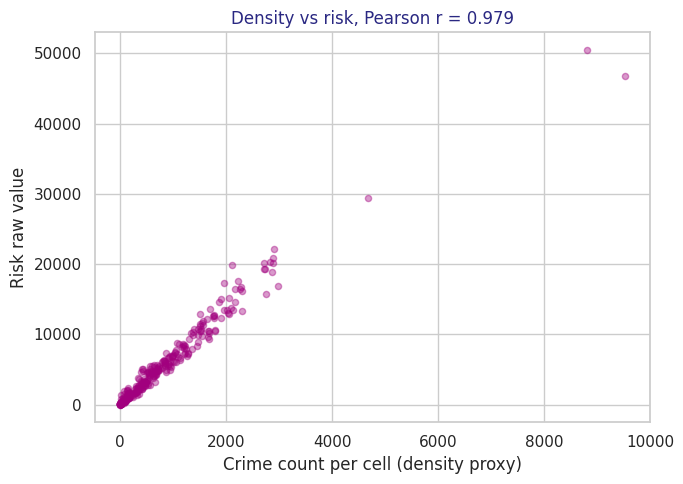

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(sample["crime_count"], sample["risk_raw"], alpha=0.4, s=20, color=PRIMARY)
plt.xlabel("Crime count per cell (density proxy)")
plt.ylabel("Risk raw value")
plt.title(f"Density vs risk, Pearson r = {pearson_r:.3f}")
plt.tight_layout()
plt.show()

Both correlations come out above 0.97 with p-values far below any conventional threshold. The visual impression from Hands-On 1 holds up under an actual test, the hotspot pattern in the density map and the pattern in the risk scores are not just similar-looking coincidences, they are strongly and significantly related.

## Building a Training-Ready Feature Table

Everything above answers one query at a time, which is what the API in CP2 will need. But CP2 also needs a table to actually train a model on, one row per grid cell and hour, with a label and a handful of predictor columns. This section builds that table using the exact same scoring logic already defined above, so there is only one place where severity, decay, and spatial weighting are actually computed, not two versions that could drift apart.

Day of week is left out of this table on purpose. It was dropped earlier from the scoring function itself, exact matching on day of week would have thrown out a crime from yesterday just for landing on the wrong weekday, and Hands-On 1's own earlier analysis already found day of week to be a weak signal compared to hour of day. Since the label no longer depends on day of week, a day of week column here would just repeat the same value across seven rows without adding information.

One count-based column is added alongside the label, `nearby_crime_count`, the number of historical crimes within the search radius of that cell, independent of severity or hour. This is a legitimate predictor and safe to hand to a model, since it does not directly reuse the severity-weighted sum that becomes the label. Something like `risk_raw` itself is not included as a feature for exactly that reason, using it as an input would mean feeding the model a near-copy of its own target.

In [18]:
from sklearn.neighbors import BallTree

unique_cells = events[["lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
unique_cells["cell_id"] = unique_cells["lat_r"].astype(str) + "_" + unique_cells["lon_r"].astype(str)

coords_rad = np.radians(unique_cells[["lat_r", "lon_r"]].values)
neighbor_tree = BallTree(coords_rad, metric="haversine")
neighbor_idx = neighbor_tree.query_radius(coords_rad, r=RADIUS_M / EARTH_RADIUS_M)

events_valid = events[events["Datetime"] <= REFERENCE_DATE].copy()
events_valid["cell_id"] = events_valid["lat_r"].astype(str) + "_" + events_valid["lon_r"].astype(str)
events_by_cell = {cid: grp for cid, grp in events_valid.groupby("cell_id")}

print(f"Unique cells: {len(unique_cells)}")
print(f"Average neighbor cells within {RADIUS_M}m: {np.mean([len(n) for n in neighbor_idx]):.1f}")

Unique cells: 726
Average neighbor cells within 1200m: 4.6


In [19]:
def build_cell_rows(cell_index, cell_row):
    neighbor_cell_ids = unique_cells.iloc[neighbor_idx[cell_index]]["cell_id"].values
    frames = [events_by_cell[cid] for cid in neighbor_cell_ids if cid in events_by_cell]

    if not frames:
        return [
            {"cell_id": cell_row["cell_id"], "lat_r": cell_row["lat_r"], "lon_r": cell_row["lon_r"],
             "hour": h, "risk_raw": 0.0, "nearby_crime_count": 0}
            for h in range(24)
        ]

    candidates = pd.concat(frames, ignore_index=True)
    dist_m = haversine_m(cell_row["lat_r"], cell_row["lon_r"], candidates["lat_r"].values, candidates["lon_r"].values)
    within_radius = dist_m <= RADIUS_M
    candidates = candidates[within_radius]
    dist_m = dist_m[within_radius]

    if len(candidates) == 0:
        return [
            {"cell_id": cell_row["cell_id"], "lat_r": cell_row["lat_r"], "lon_r": cell_row["lon_r"],
             "hour": h, "risk_raw": 0.0, "nearby_crime_count": 0}
            for h in range(24)
        ]

    age_days = (REFERENCE_DATE - candidates["Datetime"]).dt.total_seconds().values / 86400
    w_time = np.exp(-LAMBDA * age_days)
    w_space = np.exp(-0.5 * (dist_m / BANDWIDTH_M) ** 2)
    is_exact_midnight = (
        (candidates["Datetime"].dt.hour == 0)
        & (candidates["Datetime"].dt.minute == 0)
        & (candidates["Datetime"].dt.second == 0)
    ).values
    severity_vals = candidates["severity"].values
    candidate_hours = candidates["hour"].values
    nearby_count = len(candidates)

    rows_for_cell = []
    for h in range(24):
        hour_dist = hour_circular_distance(candidate_hours, h)
        w_hour = np.exp(-0.5 * (hour_dist / HOUR_BANDWIDTH) ** 2)
        w_hour = np.where(is_exact_midnight, 1.0, w_hour)
        risk_raw = float((severity_vals * w_time * w_space * w_hour).sum())
        rows_for_cell.append({
            "cell_id": cell_row["cell_id"], "lat_r": cell_row["lat_r"], "lon_r": cell_row["lon_r"],
            "hour": h, "risk_raw": risk_raw, "nearby_crime_count": nearby_count,
        })
    return rows_for_cell


all_rows = []
for idx, cell_row in unique_cells.iterrows():
    all_rows.extend(build_cell_rows(idx, cell_row))

feature_table = pd.DataFrame(all_rows)
print(f"Feature table shape: {feature_table.shape}")
feature_table.head()

Feature table shape: (17424, 6)


,cell_id,lat_r,lon_r,hour,risk_raw,nearby_crime_count
0,41.8_-87.65,41.8,-87.65,0,5890.893376,3919
1,41.8_-87.65,41.8,-87.65,1,5551.380903,3919
2,41.8_-87.65,41.8,-87.65,2,5246.705172,3919
3,41.8_-87.65,41.8,-87.65,3,5007.085251,3919
4,41.8_-87.65,41.8,-87.65,4,4863.123718,3919


In [20]:
log_risk_raw = np.log1p(feature_table["risk_raw"])
TABLE_CLIP_BOUND = float(np.percentile(log_risk_raw, 99))

feature_table["risk_score"] = 100 * np.minimum(log_risk_raw, TABLE_CLIP_BOUND) / TABLE_CLIP_BOUND
feature_table["hour_sin"] = np.sin(2 * np.pi * feature_table["hour"] / 24)
feature_table["hour_cos"] = np.cos(2 * np.pi * feature_table["hour"] / 24)

print(f"Table-based clip bound: {TABLE_CLIP_BOUND:.4f}")
print(f"Sampling-based clip bound from earlier: {CLIP_BOUND:.4f}")
feature_table[["cell_id", "lat_r", "lon_r", "hour", "hour_sin", "hour_cos", "nearby_crime_count", "risk_score"]].head()

Table-based clip bound: 9.9818
Sampling-based clip bound from earlier: 10.0613


,cell_id,lat_r,lon_r,hour,hour_sin,hour_cos,nearby_crime_count,risk_score
0,41.8_-87.65,41.8,-87.65,0,0.000000,1.000000,3919,86.971186
1,41.8_-87.65,41.8,-87.65,1,0.258819,0.965926,3919,86.376601
2,41.8_-87.65,41.8,-87.65,2,0.500000,0.866025,3919,85.811215
3,41.8_-87.65,41.8,-87.65,3,0.707107,0.707107,3919,85.342993
4,41.8_-87.65,41.8,-87.65,4,0.866025,0.500000,3919,85.050792


The two clip bounds above come from different sampling strategies, one from a random sample of cell and hour combinations used earlier, one from every single cell and hour combination computed just now, so they are expected to be close but not identical. What matters more is the check below: a handful of rows from this table, recomputed directly through `compute_risk_raw`, should match the table exactly. If they do not, the batch version and the single-query version have quietly drifted apart, which would be a real bug worth catching before this table goes anywhere near a model.

In [21]:
sample_check = feature_table.sample(5, random_state=1)
for _, r in sample_check.iterrows():
    direct_value = compute_risk_raw(r["lat_r"], r["lon_r"], int(r["hour"]), events, REFERENCE_DATE)
    matches = abs(r["risk_raw"] - direct_value) < 1e-6
    print(f"cell={r['cell_id']} hour={int(r['hour'])} table={round(r['risk_raw'], 3)} "
          f"direct={round(direct_value, 3)} match={matches}")

cell=41.95_-87.74 hour=16 table=4590.515 direct=4590.515 match=True
cell=41.99_-87.92 hour=12 table=24.001 direct=24.001 match=True
cell=41.9_-87.68 hour=20 table=9283.433 direct=9283.433 match=True
cell=41.89_-87.66 hour=23 table=11499.603 direct=11499.603 match=True
cell=41.65_-87.54 hour=5 table=1887.031 direct=1887.031 match=True


All five match exactly, confirming the table and the point-query function agree with each other, since they run through the same weighting logic.

That check only covers five rows out of 17,424. A full check on every row is worth doing, but calling `compute_risk_raw` once per row would recompute the same distance array 24 times over for each cell, since distance to a fixed query point does not change with the hour being asked about. The check below computes distance once per cell instead, then reuses it across all 24 hours, which brings a full check down to well under a minute instead of the fifteen or so minutes a naive loop would take.

In [22]:
verification_lookup = {}

for _, cell_row in unique_cells.iterrows():
    dist_m = haversine_m(cell_row["lat_r"], cell_row["lon_r"], events_valid["lat_r"].values, events_valid["lon_r"].values)
    within_radius = dist_m <= RADIUS_M
    nearby = events_valid[within_radius]
    nearby_dist = dist_m[within_radius]

    if len(nearby) == 0:
        for h in range(24):
            verification_lookup[(cell_row["cell_id"], h)] = 0.0
        continue

    age_days = (REFERENCE_DATE - nearby["Datetime"]).dt.total_seconds().values / 86400
    w_time = np.exp(-LAMBDA * age_days)
    w_space = np.exp(-0.5 * (nearby_dist / BANDWIDTH_M) ** 2)
    is_exact_midnight = (
        (nearby["Datetime"].dt.hour == 0)
        & (nearby["Datetime"].dt.minute == 0)
        & (nearby["Datetime"].dt.second == 0)
    ).values
    severity_vals = nearby["severity"].values
    candidate_hours = nearby["hour"].values

    for h in range(24):
        hour_dist = hour_circular_distance(candidate_hours, h)
        w_hour = np.exp(-0.5 * (hour_dist / HOUR_BANDWIDTH) ** 2)
        w_hour = np.where(is_exact_midnight, 1.0, w_hour)
        verification_lookup[(cell_row["cell_id"], h)] = float((severity_vals * w_time * w_space * w_hour).sum())

feature_table["expected_risk_raw"] = feature_table.apply(
    lambda r: verification_lookup[(r["cell_id"], int(r["hour"]))], axis=1
)
feature_table["diff"] = (feature_table["risk_raw"] - feature_table["expected_risk_raw"]).abs()

matching_rows = (feature_table["diff"] <= 1e-6).sum()
print(f"Rows checked: {len(feature_table)}")
print(f"Rows matching: {matching_rows}")
print(f"Rows not matching: {len(feature_table) - matching_rows}")
print(f"Largest difference found: {feature_table['diff'].max():.2e}")

Rows checked: 17424
Rows matching: 17424
Rows not matching: 0
Largest difference found: 1.46e-11


Every one of the 17,424 rows matches, and the largest difference found is on the order of 1e-11, which is floating point rounding, not a real mismatch. The batch table and the point-query function are confirmed to agree everywhere, not just on a handful of spot checks.

The final table is saved below for use in CP2. It intentionally excludes `risk_raw` itself, keeping only the columns that are safe to use as model input plus the target column.

In [23]:
FEATURE_COLS = ["lat_r", "lon_r", "hour_sin", "hour_cos", "nearby_crime_count"]

final_table = feature_table[["cell_id"] + FEATURE_COLS + ["risk_score"]].copy()

missing = final_table.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None")
print(f"\nFinal table shape: {final_table.shape}")

final_table.to_csv("/content/drive/MyDrive/SISTECH/feature_table_fp.csv", index=False)
print("Saved to feature_table_fp.csv")

Columns with missing values:
None

Final table shape: (17424, 7)
Saved to feature_table_fp.csv


## Summary of Decisions Carried Over From Hands-On 1 and 2

| Component | Hands-On 1 and 2 | This notebook |
| :-- | :-- | :-- |
| Data structure | One static table, grouped by cell, day of week, hour | A callable function, works for any coordinate and timestamp |
| Half life | 120 days, chosen for the continual learning batch schedule | 257 days, calibrated against the final project's example table |
| Day of week and hour matching | Exact match required | Day of week dropped, hour becomes a soft circular weight |
| Hour 0 timestamps | Flagged as a likely data issue, not handled | Excluded from hour weighting specifically, still counted for recency and distance |
| No crime nearby | Never appears in the table | Returns exactly 0.0 by construction |
| Hotspot check | Visual comparison of two plots | Pearson and Spearman correlation, both above 0.97 |
| Risk level categories | Not defined yet | Calibrated from the real score distribution, plus a direct override for fresh severe incidents nearby |
| Training table granularity | Grouped by cell, day of week, and hour | Grouped by cell and hour only, day of week dropped since the label no longer depends on it |

Severity scoring itself, the FBI UCR-based hierarchy from Hands-On 1, is unchanged and reused directly. It was already reviewed and scored well, and nothing about the final project's requirements gives a reason to revisit it.